### Nhóm 2
### Demo Condensed Nearest Neighbor (CNN) cho bộ dữ liệu Shuttle
Nội dung bao gồm:
- Dataset: Shuttle
- Khảo sát nhanh dữ liệu
- kNN baseline
- Condensed Nearest Neighbor (CNN)
- Trực quan hóa kết quả
- So sánh kết quả
- Lưu mô hình

### Khởi tạo và thư viện

In [6]:
## Thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
import time
import warnings
warnings.filterwarnings('ignore')

import joblib as jlb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

sbn.set_style('whitegrid')

### Đọc dữ liệu 

In [7]:
## Đọc dữ liệu Shuttle
train_path = 'Data/train_shuttle.csv'
test_path  = 'Data/test_shuttle.csv'

train_df = pd.read_csv(train_path, header=None)
test_df  = pd.read_csv(test_path, header=None)

## Đặt tên cột: f1..fN và label
n_cols = train_df.shape[1]
feature_cols = [f'f{i}' for i in range(1, n_cols)]
train_df.columns = feature_cols + ['label']
test_df.columns = feature_cols + ['label']

print('** Thông tin dữ liệu train:')
print(train_df.info())
print('** Dữ liệu mẫu:')
print(train_df.head())

** Thông tin dữ liệu train:
<class 'pandas.DataFrame'>
RangeIndex: 43500 entries, 0 to 43499
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   f1      43500 non-null  int64
 1   f2      43500 non-null  int64
 2   f3      43500 non-null  int64
 3   f4      43500 non-null  int64
 4   f5      43500 non-null  int64
 5   f6      43500 non-null  int64
 6   f7      43500 non-null  int64
 7   f8      43500 non-null  int64
 8   f9      43500 non-null  int64
 9   label   43500 non-null  int64
dtypes: int64(10)
memory usage: 3.3 MB
None
** Dữ liệu mẫu:
   f1  f2  f3  f4  f5  f6  f7  f8  f9  label
0  50  21  77   0  28   0  27  48  22      2
1  55   0  92   0   0  26  36  92  56      4
2  53   0  82   0  52  -5  29  30   2      1
3  37   0  76   0  28  18  40  48   8      1
4  37   0  79   0  34 -26  43  46   2      1


** Phân bố nhãn (train):
label
1    34108
4     6748
5     2458
3      132
2       37
7       11
6        6
Name: count, dtype: int64


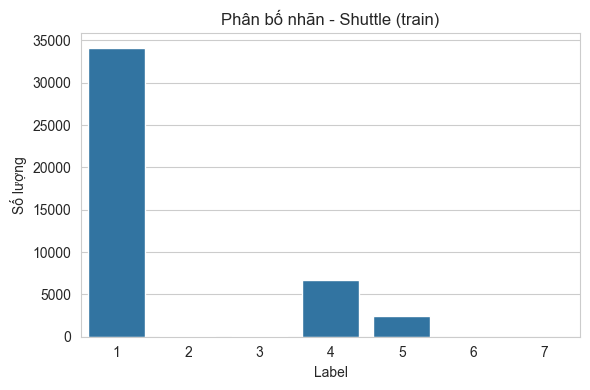

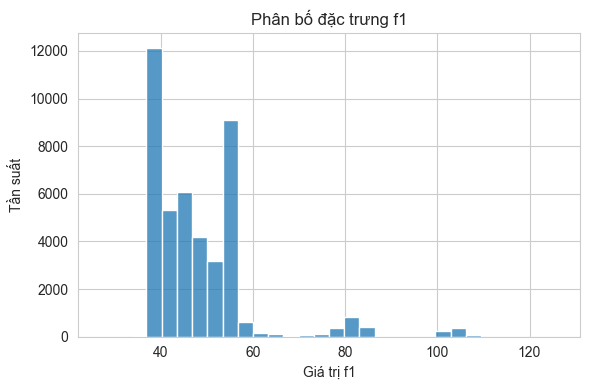

In [8]:
## Phân bố nhãn và thống kê nhanh
print('** Phân bố nhãn (train):')
print(train_df['label'].value_counts())

plt.figure(figsize=(6, 4))
sbn.countplot(data=train_df, x='label')
plt.title('Phân bố nhãn - Shuttle (train)')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sbn.histplot(data=train_df, x='f1', bins=30, kde=False)
plt.title('Phân bố đặc trưng f1')
plt.xlabel('Giá trị f1')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

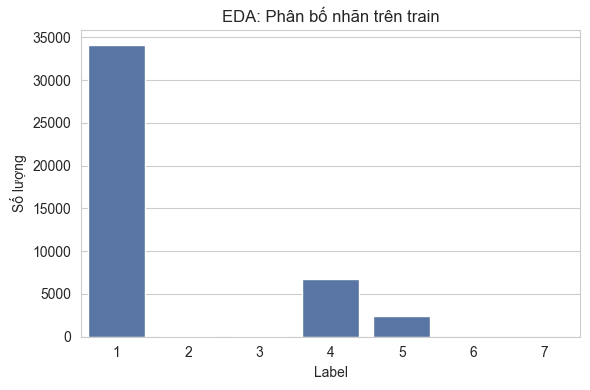

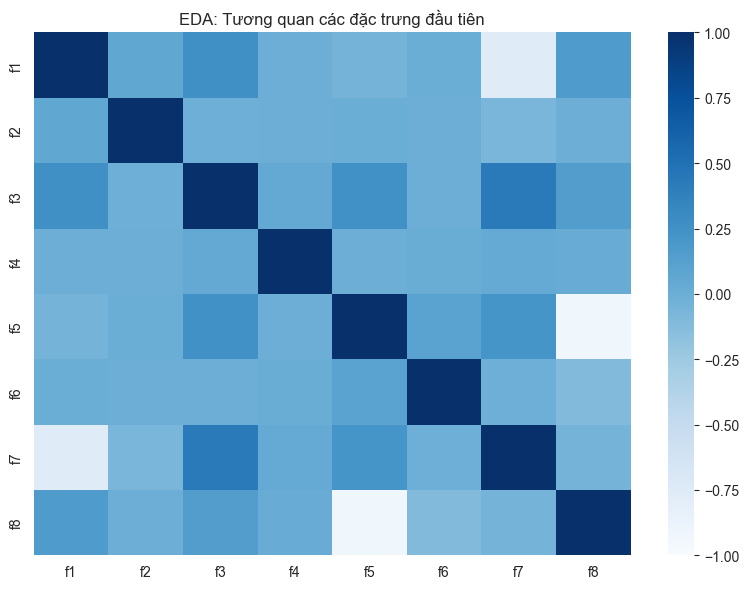

** Đã lưu: Output/cnn_dataset_summary.csv
** Đã lưu: Output/cnn_label_distribution.csv
** Đã lưu: Output/cnn_numeric_corr.png


In [25]:
## EDA tối thiểu và lưu kết quả ra Output
label_counts = train_df['label'].value_counts().sort_index()
label_summary = pd.DataFrame({
    'count': label_counts,
    'ratio': (label_counts / len(train_df)).round(6)
})
label_summary.to_csv('Output/cnn_label_distribution.csv')

dataset_summary = pd.DataFrame([
    {'dataset': 'train', 'rows': train_df.shape[0], 'cols': train_df.shape[1], 'missing_cells': int(train_df.isna().sum().sum())},
    {'dataset': 'test', 'rows': test_df.shape[0], 'cols': test_df.shape[1], 'missing_cells': int(test_df.isna().sum().sum())},
])
dataset_summary.to_csv('Output/cnn_dataset_summary.csv', index=False)

plt.figure(figsize=(6, 4))
sbn.barplot(x=label_summary.index.astype(str), y=label_summary['count'], color='#4C72B0')
plt.title('EDA: Phân bố nhãn trên train')
plt.xlabel('Label')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.savefig('Output/cnn_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

top_numeric_cols = feature_cols[:8]
plt.figure(figsize=(8, 6))
sbn.heatmap(train_df[top_numeric_cols].corr(), annot=False, cmap='Blues', vmin=-1, vmax=1)
plt.title('EDA: Tương quan các đặc trưng đầu tiên')
plt.tight_layout()
plt.savefig('Output/cnn_numeric_corr.png', dpi=150, bbox_inches='tight')
plt.show()

print('** Đã lưu: Output/cnn_dataset_summary.csv')
print('** Đã lưu: Output/cnn_label_distribution.csv')
print('** Đã lưu: Output/cnn_numeric_corr.png')

### Tách dữ liệu và chuẩn bị đầu vào

In [10]:
## Chuẩn bị X, y
X_train = train_df[feature_cols].values
y_train = train_df['label'].values

X_test = test_df[feature_cols].values
y_test = test_df['label'].values

print(f'** Kích thước train: {X_train.shape}')
print(f'** Kích thước test : {X_test.shape}')

** Kích thước train: (43500, 9)
** Kích thước test : (14500, 9)


### kNN baseline

In [11]:
## Huấn luyện kNN baseline
knn_base = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_base.fit(X_train, y_train)

y_pred_base = knn_base.predict(X_test)

acc = accuracy_score(y_test, y_pred_base)
prec = precision_score(y_test, y_pred_base, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred_base, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred_base, average='macro', zero_division=0)

print('=== Kết quả kNN baseline ===')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_base))

=== Kết quả kNN baseline ===
Accuracy : 0.9983
Precision: 0.8576
Recall   : 0.8696
F1-score : 0.8529

Confusion Matrix:
[[11469     1     3     4     0     0     1]
 [    1    12     0     0     0     0     0]
 [    3     0    36     0     0     0     0]
 [    2     0     0  2151     2     0     0]
 [    3     0     0     1   804     1     0]
 [    0     0     0     0     3     1     0]
 [    0     0     0     0     0     0     2]]


### Ma trận nhầm lẫn - kNN baseline

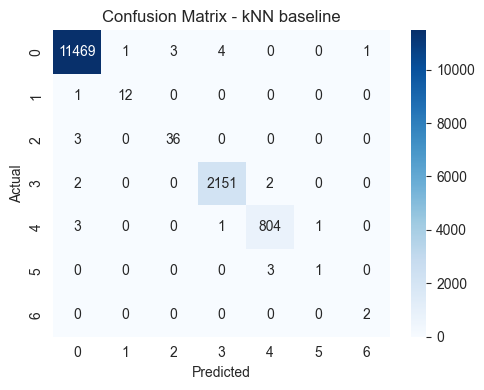

In [12]:
## Confusion matrix (kNN baseline)
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(5, 4))
sbn.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - kNN baseline')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Condensed Nearest Neighbor (CNN)


- CNN chỉ rút gọn tập train bằng 1-NN để giữ mẫu quan trọng ở biên quyết định.
- CNN không phải mô hình phân loại, nên không có Accuracy/Precision trực tiếp.
- Vì vậy tách ra 2 phần rút gọn dữ liệu và huấn luyện kNN trên tập rút gọn.

In [13]:
## Thuật toán Condensed Nearest Neighbor (1-NN)
def condensed_nearest_neighbor(X, y, metric='euclidean', max_iters=10):
    y = np.array(y)
    classes = np.unique(y)

    ## Khởi tạo: lấy 1 mẫu cho mỗi lớp
    idx_init = []
    for c in classes:
        idx_init.append(np.where(y == c)[0][0])

    S_idx = list(dict.fromkeys(idx_init))
    S_set = set(S_idx)

    it = 0
    changed = True
    while changed and it < max_iters:
        changed = False
        it += 1

        knn = KNeighborsClassifier(n_neighbors=1, metric=metric)
        knn.fit(X[S_idx], y[S_idx])

        for i in range(X.shape[0]):
            if i in S_set:
                continue
            pred = knn.predict([X[i]])
            if pred[0] != y[i]:
                S_idx.append(i)
                S_set.add(i)
                changed = True

        print(f'  Vòng {it}: |S| = {len(S_idx)}')

    return np.array(S_idx)

In [14]:
## Rút gọn tập train bằng CNN
cnn_idx = condensed_nearest_neighbor(X_train, y_train, metric='euclidean', max_iters=8)

X_train_cnn = X_train[cnn_idx]
y_train_cnn = y_train[cnn_idx]

reduction_ratio = 1 - (X_train_cnn.shape[0] / X_train.shape[0])

print(f'** Kích thước train ban đầu: {X_train.shape[0]}')
print(f'** Kích thước train sau CNN: {X_train_cnn.shape[0]}')
print(f'** Tỉ lệ rút gọn: {reduction_ratio:.2%}')

  Vòng 1: |S| = 13488
  Vòng 2: |S| = 23508
  Vòng 3: |S| = 23509
  Vòng 4: |S| = 23509
** Kích thước train ban đầu: 43500
** Kích thước train sau CNN: 23509
** Tỉ lệ rút gọn: 45.96%


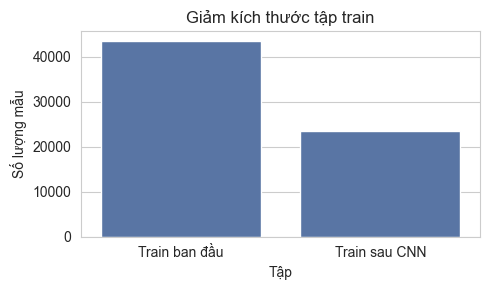

In [15]:
## Biểu đồ kích thước tập train trước/sau CNN
size_df = pd.DataFrame({
    'Tập': ['Train ban đầu', 'Train sau CNN'],
    'Số lượng': [X_train.shape[0], X_train_cnn.shape[0]]
})

plt.figure(figsize=(5, 3))
sbn.barplot(data=size_df, x='Tập', y='Số lượng', color='#4C72B0')
plt.title('Giảm kích thước tập train')
plt.ylabel('Số lượng mẫu')
plt.tight_layout()
plt.show()

In [16]:
## Phân loại trên tập đã rút gọn (kNN)
knn_cnn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_cnn.fit(X_train_cnn, y_train_cnn)

y_pred_cnn = knn_cnn.predict(X_test)

acc_cnn = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn, average='macro', zero_division=0)
rec_cnn = recall_score(y_test, y_pred_cnn, average='macro', zero_division=0)
f1_cnn = f1_score(y_test, y_pred_cnn, average='macro', zero_division=0)

print('\n=== Kết quả kNN (train trên CNN) ===')
print(f'Accuracy : {acc_cnn:.4f}')
print(f'Precision: {prec_cnn:.4f}')
print(f'Recall   : {rec_cnn:.4f}')
print(f'F1-score : {f1_cnn:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred_cnn))


=== Kết quả kNN (train trên CNN) ===
Accuracy : 0.9980
Precision: 0.8466
Recall   : 0.8583
F1-score : 0.8417

Confusion Matrix:
[[11469     1     3     4     0     0     1]
 [    1    11     0     1     0     0     0]
 [    3     0    36     0     0     0     0]
 [    4     0     0  2149     2     0     0]
 [    3     1     0     1   803     1     0]
 [    0     0     0     0     3     1     0]
 [    0     0     0     0     0     0     2]]


### Ma trận nhầm lẫn - kNN (train trên CNN)

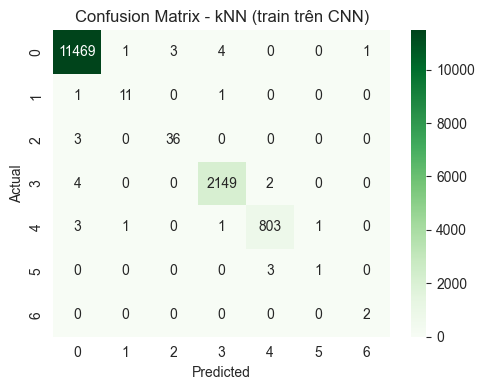

In [17]:
## Confusion matrix (kNN train trên CNN)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(5, 4))
sbn.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - kNN (train trên CNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### So sánh kết quả

### So sánh thời gian train & dự đoán

** Train time kNN baseline: 222.2 ms
** Pred time  kNN baseline: 1641.0 ms
** Train time kNN train trên CNN: 81.5 ms
** Pred time  kNN train trên CNN: 1765.5 ms


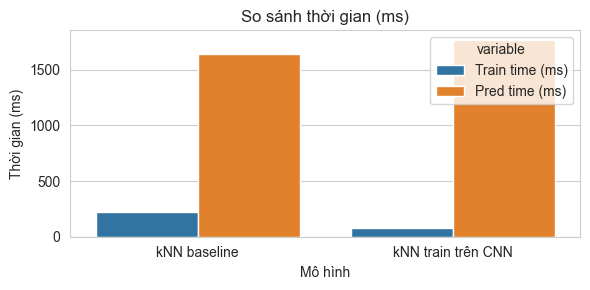

In [18]:
## So sánh thời gian train & dự đoán (ms)
knn_base_time = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
start = time.perf_counter()
knn_base_time.fit(X_train, y_train)
train_base_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
_ = knn_base_time.predict(X_test)
pred_base_ms = (time.perf_counter() - start) * 1000

knn_cnn_time = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
start = time.perf_counter()
knn_cnn_time.fit(X_train_cnn, y_train_cnn)
train_cnn_ms = (time.perf_counter() - start) * 1000

start = time.perf_counter()
_ = knn_cnn_time.predict(X_test)
pred_cnn_ms = (time.perf_counter() - start) * 1000

print(f'** Train time kNN baseline: {train_base_ms:.1f} ms')
print(f'** Pred time  kNN baseline: {pred_base_ms:.1f} ms')
print(f'** Train time kNN train trên CNN: {train_cnn_ms:.1f} ms')
print(f'** Pred time  kNN train trên CNN: {pred_cnn_ms:.1f} ms')

time_df = pd.DataFrame({
    'Mô hình': ['kNN baseline', 'kNN train trên CNN'],
    'Train time (ms)': [train_base_ms, train_cnn_ms],
    'Pred time (ms)': [pred_base_ms, pred_cnn_ms]
})

time_long = time_df.melt(id_vars='Mô hình', var_name='variable', value_name='Thời gian (ms)')

plt.figure(figsize=(6, 3))
sbn.barplot(data=time_long, x='Mô hình', y='Thời gian (ms)', hue='variable')
plt.title('So sánh thời gian (ms)')
plt.ylabel('Thời gian (ms)')
plt.tight_layout()
plt.show()

             Mô hình  Accuracy  Precision  Recall  F1-score  Train size
        kNN baseline    0.9983     0.8576  0.8696    0.8529       43500
kNN (train trên CNN)    0.9980     0.8466  0.8583    0.8417       23509


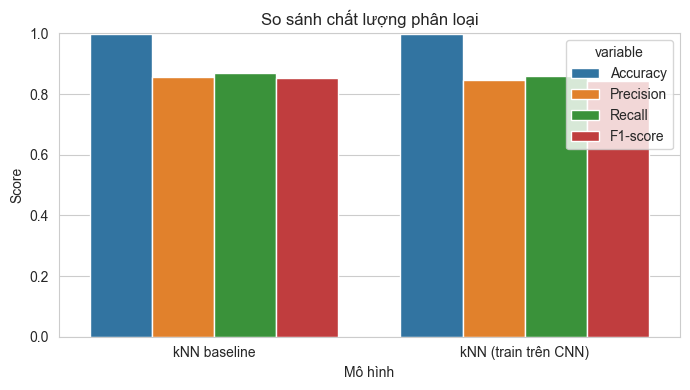

In [24]:
## Bảng so sánh
summary = pd.DataFrame({
    'Mô hình': ['kNN baseline', 'kNN (train trên CNN)'],
    'Accuracy': [round(acc, 4), round(acc_cnn, 4)],
    'Precision': [round(prec, 4), round(prec_cnn, 4)],
    'Recall': [round(rec, 4), round(rec_cnn, 4)],
    'F1-score': [round(f1, 4), round(f1_cnn, 4)],
    'Train size': [X_train.shape[0], X_train_cnn.shape[0]]
})
print(summary.to_string(index=False))

## Biểu đồ so sánh nhanh
plt.figure(figsize=(7, 4))
sbn.barplot(
    data=summary.melt(id_vars='Mô hình', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score']),
    x='Mô hình',
    y='value',
    hue='variable'
)
plt.title('So sánh chất lượng phân loại')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.tight_layout()
summary.to_csv('Output/cnn_comparison_summary.csv', index=False)
plt.show()

#### ROC/AUC (đa lớp, OvR)


** AUC macro kNN baseline: 0.9979
** AUC macro kNN train trên CNN: 0.9979


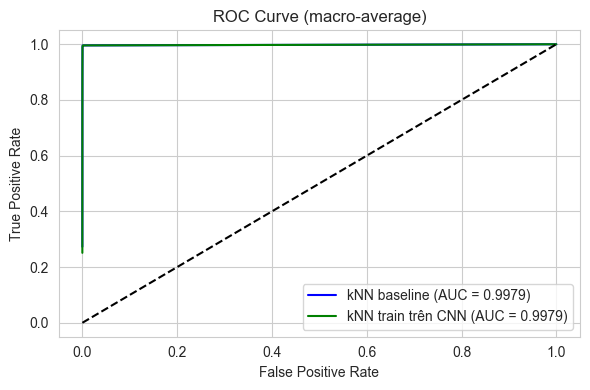

In [20]:
## ROC/AUC macro-average (multi-class, OvR)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

y_score_base = knn_base.predict_proba(X_test)
y_score_cnn = knn_cnn.predict_proba(X_test)

fpr_base, tpr_base, auc_base = {}, {}, {}
for i in range(n_classes):
    fpr_base[i], tpr_base[i], _ = roc_curve(y_test_bin[:, i], y_score_base[:, i])
    auc_base[i] = auc(fpr_base[i], tpr_base[i])

all_fpr_base = np.unique(np.concatenate([fpr_base[i] for i in range(n_classes)]))
mean_tpr_base = np.zeros_like(all_fpr_base)
for i in range(n_classes):
    mean_tpr_base += np.interp(all_fpr_base, fpr_base[i], tpr_base[i])
mean_tpr_base /= n_classes
fpr_base['macro'] = all_fpr_base
tpr_base['macro'] = mean_tpr_base
auc_base['macro'] = auc(fpr_base['macro'], tpr_base['macro'])

fpr_cnn, tpr_cnn, auc_cnn = {}, {}, {}
for i in range(n_classes):
    fpr_cnn[i], tpr_cnn[i], _ = roc_curve(y_test_bin[:, i], y_score_cnn[:, i])
    auc_cnn[i] = auc(fpr_cnn[i], tpr_cnn[i])

all_fpr_cnn = np.unique(np.concatenate([fpr_cnn[i] for i in range(n_classes)]))
mean_tpr_cnn = np.zeros_like(all_fpr_cnn)
for i in range(n_classes):
    mean_tpr_cnn += np.interp(all_fpr_cnn, fpr_cnn[i], tpr_cnn[i])
mean_tpr_cnn /= n_classes
fpr_cnn['macro'] = all_fpr_cnn
tpr_cnn['macro'] = mean_tpr_cnn
auc_cnn['macro'] = auc(fpr_cnn['macro'], tpr_cnn['macro'])

print(f"** AUC macro kNN baseline: {auc_base['macro']:.4f}")
print(f"** AUC macro kNN train trên CNN: {auc_cnn['macro']:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(fpr_base['macro'], tpr_base['macro'], 'b-', label=f"kNN baseline (AUC = {auc_base['macro']:.4f})")
plt.plot(fpr_cnn['macro'], tpr_cnn['macro'], 'g-', label=f"kNN train trên CNN (AUC = {auc_cnn['macro']:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (macro-average)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#### Lưu mô hình

In [21]:
## Lưu mô hình 
jlb.dump(knn_cnn, 'Output/CNN_Shuttle.mdl')

print('** Đã lưu mô hình vào Output/CNN_Shuttle.mdl')

** Đã lưu mô hình vào Output/CNN_Shuttle.mdl


##### *Nạp lại mô hình đã lưu*

In [22]:
## Nạp lại mô hình (demo sử dụng lại)
model_loaded = jlb.load('Output/CNN_Shuttle.mdl')

## Dự đoán thử trên tập test
y_pred_loaded = model_loaded.predict(X_test)

acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f'** Accuracy (model nạp lại): {acc_loaded:.4f}')

** Accuracy (model nạp lại): 0.9980


### Kết luận
- CNN giúp giảm kích thước tập train, từ đó giảm thời gian dự đoán của kNN.
- Chất lượng phân loại có thể giảm nhẹ hoặc tương đương tùy cấu hình và dữ liệu.
- Cần cân nhắc lựa chọn kNN và tham số k phù hợp.
